# Deepfake Detection Educational Journey  
## Part 2: Deep Learning Benchmarks on the FULL Dataset (~726 videos)

We now leave handcrafted features behind and let neural networks discover the patterns automatically.

Models benchmarked:
2. CNN+LSTM → adds spatial and temporal understanding

All trained on the **full dataset** with identical data pipeline.

In [ ]:
# Secure API Credentials
import os
from getpass import getpass

# This creates a secure input box so you don't have to edit the code
os.environ['KAGGLE_USERNAME'] = input('daveasmero: ')
os.environ['KAGGLE_KEY'] = getpass('KGAT_91e238b38f17f79bce1697e73e39787f: ')

print("Credentials set successfully!")

daveasmero: u
KGAT_91e238b38f17f79bce1697e73e39787f: ··········
Credentials set successfully!


In [ ]:
#  Dependencies & Dataset Download
!pip install -q kaggle opencv-python-headless matplotlib seaborn pandas numpy scipy
print("Downloading DFD Dataset (FaceForensics++ variant)...")

!kaggle datasets download -d sanikatiwarekar/deep-fake-detection-dfd-entire-original-dataset
!unzip -q deep-fake-detection-dfd-entire-original-dataset.zip -d /content/dfd
!rm deep-fake-detection-dfd-entire-original-dataset.zip
print("Data extracted to /content/dfd")

Dataset URL: https://www.kaggle.com/datasets/sanikatiwarekar/deep-fake-detection-dfd-entire-original-dataset
License(s): MIT
100% 22.5G/22.5G [03:36<00:00, 111MB/s]

Data extracted to /content/dfd


In [ ]:
# Cell 0: Install necessary libraries
!pip install -q ultralytics mediapipe

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 7.6 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import urllib.request
from PIL import Image
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from ultralytics import YOLO
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Environment ready. Using: {device}")

# Fast Data Retrieval
if not os.path.exists('/content/dfd'):
    print("Downloading dataset to local SSD...")
    !kaggle datasets download -d sanikatiwarekar/deep-fake-detection-dfd-entire-original-dataset
    !unzip -q deep-fake-detection-dfd-entire-original-dataset.zip -d /content/dfd
    !rm deep-fake-detection-dfd-entire-original-dataset.zip

# Define paths for Colab
REAL_ROOT = "/content/dfd/DFD_original sequences"
FAKE_ROOT = "/content/dfd/DFD_manipulated_sequences/DFD_manipulated_sequences"
OUT_ROOT = "/content/extracted_faces"

for label in ["0", "1"]:
    os.makedirs(os.path.join(OUT_ROOT, label), exist_ok=True)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Environment ready. Using: cpu


In [ ]:
from huggingface_hub import hf_hub_download
import os

# 1. Download YOLOv8-face weights from a reliable Hugging Face repo
print("Downloading YOLOv8 Face weights from Hugging Face...")
weights_path = hf_hub_download(repo_id="arnabdhar/YOLOv8-Face-Detection", filename="model.pt")

# 2. Initialize the model using the downloaded path
yolo_model = YOLO(weights_path).to(device)

# 3. MediaPipe setup (using your existing logic but with a small tweak for reliability)
model_url = "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task"
model_path = "face_landmarker.task"

if not os.path.exists(model_path):
    import urllib.request
    urllib.request.urlretrieve(model_url, model_path)

base_options = python.BaseOptions(model_asset_path=model_path)
options = vision.FaceLandmarkerOptions(base_options=base_options, num_faces=1)
detector = vision.FaceLandmarker.create_from_options(options)

print("Models loaded successfully!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.pt:   0%|          | 0.00/6.25M [00:00<?, ?B/s]

Models loaded successfully!


In [ ]:
def get_aligned_face(frame):
    results = yolo_model(frame, verbose=False, device=device)
    if not results[0].boxes: return None

    # Get box and add padding safely
    box = results[0].boxes.xyxy[0].cpu().numpy().astype(int)
    h, w = frame.shape[:2]
    x1, y1, x2, y2 = max(0, box[0]-20), max(0, box[1]-20), min(w, box[2]+20), min(h, box[3]+20)

    face = frame[y1:y2, x1:x2]
    if face.size == 0: return None

    # Align eyes using MediaPipe
    rgb_face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_face)
    land_res = detector.detect(mp_image)

    if land_res.face_landmarks:
        # Landmarks 33 and 263 are the outer corners of the eyes
        l_eye, r_eye = land_res.face_landmarks[0][33], land_res.face_landmarks[0][263]

        # Calculate angle for rotation
        dY = r_eye.y - l_eye.y
        dX = r_eye.x - l_eye.x
        angle = np.degrees(np.arctan2(dY, dX))

        # Rotate around the center of the face crop
        center = (face.shape[1] // 2, face.shape[0] // 2)
        M = cv2.getRotationMatrix2D(center, angle, 1)
        face = cv2.warpAffine(face, M, (face.shape[1], face.shape[0]), flags=cv2.INTER_CUBIC)

    return cv2.resize(face, (224, 224))

In [ ]:
import cv2


def process_videos_safely(real_root, fake_root, limit=50):
    """
    A sequential, VRAM-safe processor to prevent Colab from crashing.
    """
    for label, root in [("0", real_root), ("1", fake_root)]:
        if not os.path.exists(root):
            print(f"Skipping {label}: Path {root} not found.")
            continue

        # Reduce limit  to minimize resource consumption and time
        vids = [f for f in os.listdir(root) if f.endswith('.mp4')][:limit]

        print(f"\n Processing Label {label} ({len(vids)} videos)...")

        for v_name in tqdm(vids, desc=f"Label {label}"):
            video_path = os.path.join(root, v_name)
            cap = cv2.VideoCapture(video_path)
            count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

            if count < 16:
                cap.release()
                continue

            # Select 16 frames uniformly
            indices = np.linspace(0, count-1, 16, dtype=int)
            vid_id = v_name.split('.')[0]
            vid_dir = os.path.join(OUT_ROOT, label, vid_id)
            os.makedirs(vid_dir, exist_ok=True)

            for i, idx in enumerate(indices):
                cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
                ret, frame = cap.read()
                if not ret: break

                # GPU inference happens safely here, one frame at a time
                face = get_aligned_face(frame)
                if face is not None:
                    cv2.imwrite(os.path.join(vid_dir, f"{i:03d}.png"), face)

            cap.release()

            # CRITICAL: Clear the GPU cache after every video to prevent memory leaks
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

# Run the safe pipeline (363 Real + 363 Fake = 726 Videos Total)
process_videos_safely(REAL_ROOT, FAKE_ROOT, limit=363)


 Processing Label 0 (363 videos)...


Label 0: 100%|██████████| 363/363 [1:41:08<00:00, 16.72s/it]



 Processing Label 1 (363 videos)...


Label 1: 100%|██████████| 363/363 [1:42:27<00:00, 16.94s/it]


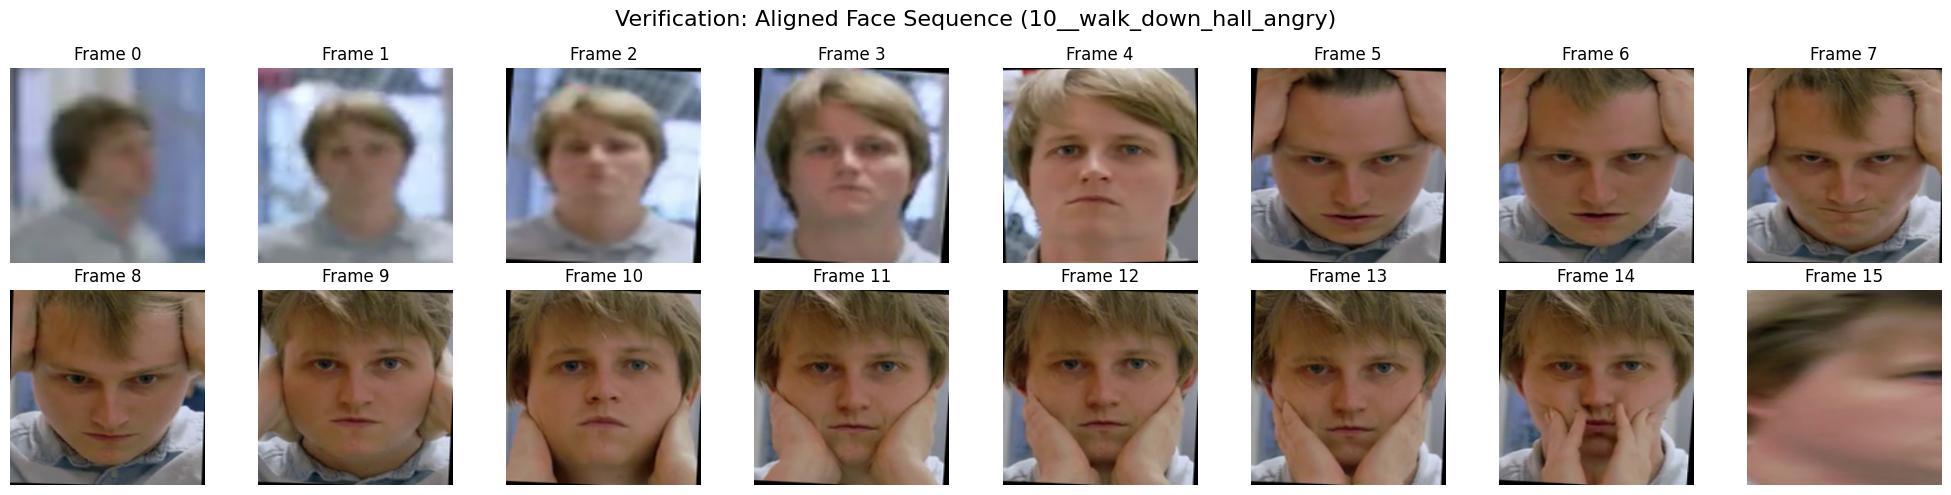

In [ ]:
import matplotlib.pyplot as plt

def verify_extraction(output_root):
    # Pick a random video folder that has content
    labels = ['0', '1']
    found_vid = None
    for l in labels:
        l_path = os.path.join(output_root, l)
        if os.path.exists(l_path) and len(os.listdir(l_path)) > 0:
            found_vid = os.path.join(l_path, os.listdir(l_path)[0])
            break

    if not found_vid:
        print("No processed videos found to verify.")
        return

    # Load and plot the 16 frames
    imgs = sorted([f for f in os.listdir(found_vid) if f.endswith('.png')])
    fig, axes = plt.subplots(2, 8, figsize=(20, 5))
    fig.suptitle(f"Verification: Aligned Face Sequence ({os.path.basename(found_vid)})", fontsize=16)

    for i, img_name in enumerate(imgs[:16]):
        img = cv2.imread(os.path.join(found_vid, img_name))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax = axes[i//8, i%8]
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(f"Frame {i}")

    plt.tight_layout()
    plt.show()

verify_extraction(OUT_ROOT)

In [ ]:
# Efficient Data Loading
class FastSequenceDataset(Dataset):
    def __init__(self, root, transform=None):
        self.samples = []
        self.transform = transform
        for label in ['0', '1']:
            l_dir = os.path.join(root, label)
            for vid in os.listdir(l_dir):
                p = os.path.join(l_dir, vid)
                if len(os.listdir(p)) >= 16:
                    self.samples.append((p, int(label)))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        imgs = sorted([os.path.join(path, f) for f in os.listdir(path)])[:16]
        frames = [self.transform(Image.open(i).convert('RGB')) for i in imgs]
        return torch.stack(frames), torch.tensor(label, dtype=torch.float)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_loader = DataLoader(FastSequenceDataset(OUT_ROOT, transform),
                          batch_size=8, shuffle=True, num_workers=4, pin_memory=True)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
from sklearn.model_selection import train_test_split
from PIL import Image

# 1. Collect all valid sequences
all_paths = []
all_labels = []

for label in ['0', '1']:
    folder_path = os.path.join(OUT_ROOT, label)
    if not os.path.exists(folder_path): continue
    for vid_id in os.listdir(folder_path):
        vid_path = os.path.join(folder_path, vid_id)
        if len(os.listdir(vid_path)) >= 16: # Ensure full sequence
            all_paths.append(vid_path)
            all_labels.append(int(label))

# 2. Strict Train/Test Split (80% Train, 20% Test)
# Stratify ensures we have an equal ratio of Real/Fake in both sets
train_paths, test_paths, train_labels, test_labels = train_test_split(
    all_paths, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)

print(f"Data Split Complete:")
print(f"Training Videos: {len(train_paths)} | Testing Videos: {len(test_paths)}")

# 3. Dynamic Dataset Class
class SplitSequenceDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        label = self.labels[idx]
        imgs = sorted([os.path.join(path, f) for f in os.listdir(path) if f.endswith('.png')])[:16]

        frames = [self.transform(Image.open(i).convert('RGB')) for i in imgs]
        return torch.stack(frames), torch.tensor(label, dtype=torch.float)

# 4. Feature Scaling (Crucial for MesoNet)
# ImageNet standardization centers the pixel data around 0 with a standard deviation of 1.
# This scales the features perfectly for the neural network gradients.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 5. Create Loaders
train_dataset = SplitSequenceDataset(train_paths, train_labels, transform=transform)
test_dataset = SplitSequenceDataset(test_paths, test_labels, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

Data Split Complete:
Training Videos: 563 | Testing Videos: 141


## Model 1: MesoNet – The Deepfake Specialist
## Model 2: CNN + LSTM – Temporal Awareness

In [ ]:
import torch.amp

# --- A. Models (Logits only, no Sigmoids for stability) ---
class Meso4(nn.Module):
    def __init__(self):
        super(Meso4, self).__init__()
        # Inception Layer 1: Different kernel sizes to catch different artifacts
        self.conv1 = nn.Conv2d(3, 8, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=5, padding=2)

        self.conv3 = nn.Conv2d(16, 32, kernel_size=5, padding=2)
        self.conv4 = nn.Conv2d(32, 64, kernel_size=5, padding=2)

        self.bn = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2, 2)
        self.leaky = nn.LeakyReLU(0.1)
        self.dropout = nn.Dropout(0.5)

        # Increased capacity in the final layers
        self.fc1 = nn.Linear(64 * 14 * 14, 128) # Assuming 224x224 input
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        x = self.leaky(self.conv1(x))
        x = self.pool(x) # 112

        x = self.leaky(self.conv2(x))
        x = self.pool(x) # 56

        x = self.leaky(self.conv3(x))
        x = self.pool(x) # 28

        x = self.leaky(self.conv4(x))
        x = self.pool(x) # 14

        x = x.view(x.size(0), -1)
        x = self.dropout(self.leaky(self.fc1(x)))
        return self.fc2(x)

class CNN_LSTM(nn.Module):
    def __init__(self):
        super().__init__()
        res = models.resnet18(weights='DEFAULT')
        self.cnn = nn.Sequential(*list(res.children())[:-1])
        self.lstm = nn.LSTM(512, 256, batch_first=True)
        self.fc = nn.Linear(256, 1)
    def forward(self, x):
        B, T, C, H, W = x.shape
        feats = self.cnn(x.view(B * T, C, H, W)).view(B, T, 512)
        _, (h_n, _) = self.lstm(feats)
        return self.fc(h_n[-1])

# Re-initializing to ensure they exist and are on the correct device
meso = Meso4().to(device)
lstm = CNN_LSTM().to(device)

print(f"Models initialized on: {device}")



Models initialized on: cpu


## Unified Training Function

In [ ]:
import torch.optim as optim
def train_and_validate_cpu(model, name, train_loader, test_loader, epochs=5, is_temporal=False):
    lr = 1e-3 if name == "MesoNet" else 1e-4
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = nn.BCEWithLogitsLoss()
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

    print(f"\n========== Training {name} (CPU Mode) ==========")
    for epoch in range(epochs):
        # TRAIN
        model.train()
        train_loss = 0
        for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
            imgs, labels = imgs.to(device), labels.to(device).unsqueeze(1)
            optimizer.zero_grad()

            if is_temporal:
                pred = model(imgs)
            else:
                B, T, C, H, W = imgs.shape
                pred = model(imgs.view(B * T, C, H, W)).view(B, T, 1).mean(dim=1)

            loss = criterion(pred, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # VALIDATE
        model.eval()
        val_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in tqdm(test_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
                imgs, labels = imgs.to(device), labels.to(device).unsqueeze(1)

                if is_temporal:
                    pred = model(imgs)
                else:
                    B, T, C, H, W = imgs.shape
                    pred = model(imgs.view(B * T, C, H, W)).view(B, T, 1).mean(dim=1)

                v_loss = criterion(pred, labels)
                val_loss += v_loss.item()

                probs = torch.sigmoid(pred)
                predictions = (probs > 0.5).float()
                correct += (predictions == labels).sum().item()
                total += labels.size(0)

        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(test_loader)
        val_acc = (correct / total) * 100
        scheduler.step(avg_val_loss)

        print(f"Summary -> Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.1f}%")

# MesoNet: 12 epochs | CNN-LSTM: 8 epochs
train_and_validate_cpu(meso, "MesoNet", train_loader, test_loader, epochs=12, is_temporal=False)
train_and_validate_cpu(lstm, "CNN-LSTM", train_loader, test_loader, epochs=8, is_temporal=True)


========== Training MesoNet (CPU Mode) ==========


Epoch 1/12 [Val]: 100%|██████████| 18/18 [00:44<00:00,  2.48s/it]


Summary -> Train Loss: 0.6981 | Val Loss: 0.6951 | Val Acc: 48.2%


Epoch 2/12 [Val]: 100%|██████████| 18/18 [00:45<00:00,  2.51s/it]


Summary -> Train Loss: 0.6955 | Val Loss: 0.6937 | Val Acc: 57.4%


...

Summary -> Train Loss: 0.0525 | Val Loss: 0.1166 | Val Acc: 95.7%


Epoch 7/8 [Val]: 100%|██████████| 18/18 [03:34<00:00, 11.93s/it]


Summary -> Train Loss: 0.0516 | Val Loss: 0.1252 | Val Acc: 92.9%


Epoch 8/8 [Val]: 100%|██████████| 18/18 [03:40<00:00, 12.25s/it]

Summary -> Train Loss: 0.0322 | Val Loss: 0.1514 | Val Acc: 95.0%


## Evaluation & Comparison

Evaluating MesoNet...


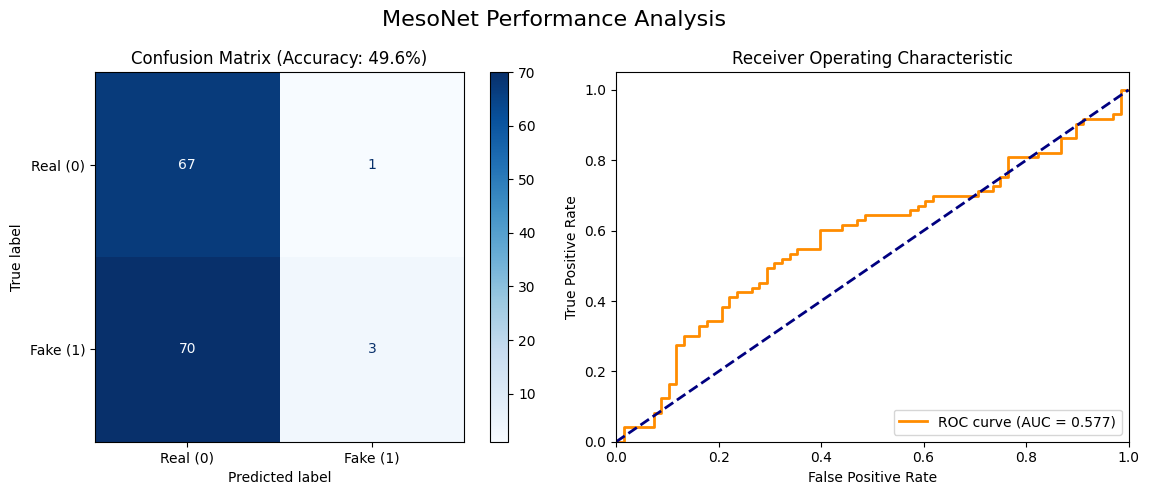

Evaluating CNN-LSTM...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


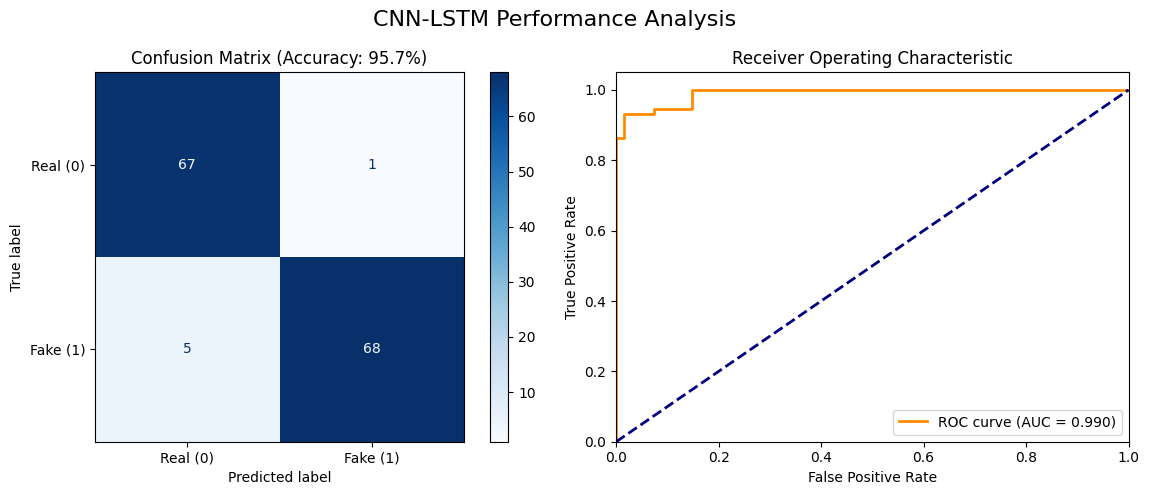

In [ ]:
#: Evaluation & Visualizations
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay

@torch.no_grad()
def evaluate_and_visualize(model, name, loader, is_temporal=False):
    model.eval()
    y_true, y_prob = [], []

    print(f"Evaluating {name}...")
    for imgs, labels in loader:
        imgs = imgs.to(device)
        if is_temporal:
            out = model(imgs)
        else:
            B, T, C, H, W = imgs.shape
            out = model(imgs.view(B * T, C, H, W)).view(B, T, 1).mean(dim=1)

        y_prob.extend(out.cpu().numpy().flatten())
        y_true.extend(labels.numpy().flatten())

    # Calculate Metrics
    y_pred = [1 if p > 0.5 else 0 for p in y_prob]
    auc = roc_auc_score(y_true, y_prob)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    cm = confusion_matrix(y_true, y_pred)

    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"{name} Performance Analysis", fontsize=16)

    # Plot 1: Confusion Matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real (0)', 'Fake (1)'])
    disp.plot(ax=axes[0], cmap='Blues', values_format='d')
    axes[0].set_title(f"Confusion Matrix (Accuracy: {(cm[0,0]+cm[1,1])/sum(sum(cm))*100:.1f}%)")

    # Plot 2: ROC Curve
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc:.3f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('Receiver Operating Characteristic')
    axes[1].legend(loc="lower right")

    plt.tight_layout()
    plt.show()

# Run Evaluations
evaluate_and_visualize(meso, "MesoNet", test_loader, is_temporal=False)
evaluate_and_visualize(lstm, "CNN-LSTM", test_loader, is_temporal=True)

 Calculating full metrics for MesoNet...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/tmp/ipykernel_173/842882357.py:21: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with torch.amp.autocast('cuda'):



--- Summary Table ---


,Accuracy,Precision,Recall,F1-Score,MCC,Avg Precision
MesoNet,0.5461,0.5495,0.6849,0.6098,0.0856,0.5921


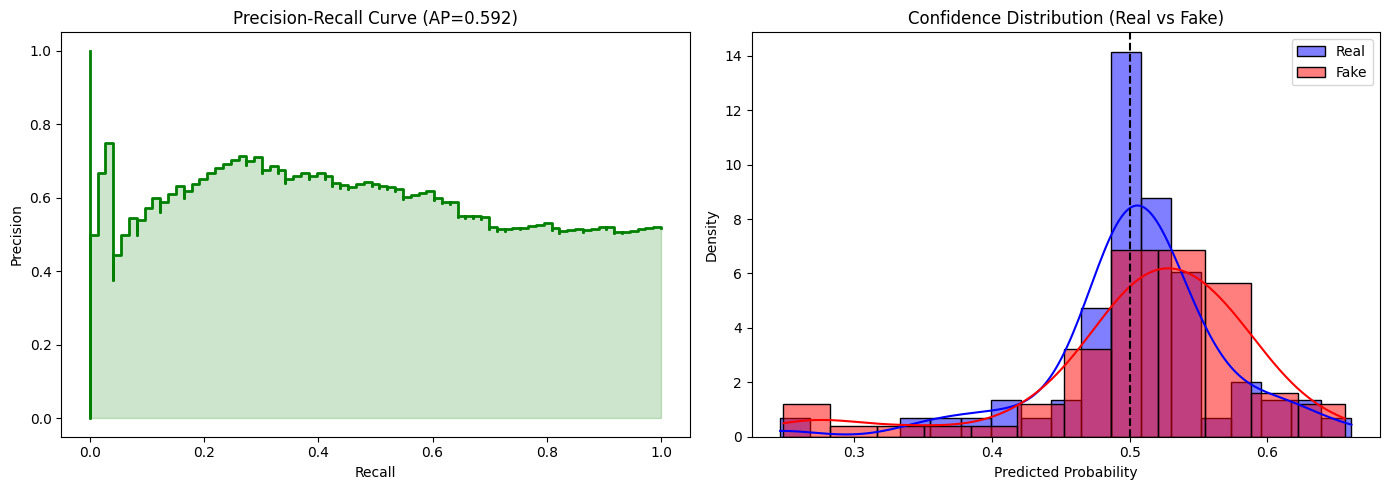


--- Detailed Classification Report ---
              precision    recall  f1-score   support

        Real       0.54      0.40      0.46        68
        Fake       0.55      0.68      0.61        73

    accuracy                           0.55       141
   macro avg       0.54      0.54      0.53       141
weighted avg       0.54      0.55      0.54       141

 Calculating full metrics for CNN-LSTM...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/tmp/ipykernel_173/842882357.py:21: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with torch.amp.autocast('cuda'):



--- Summary Table ---


,Accuracy,Precision,Recall,F1-Score,MCC,Avg Precision
CNN-LSTM,0.9504,0.9714,0.9315,0.951,0.9016,0.9913


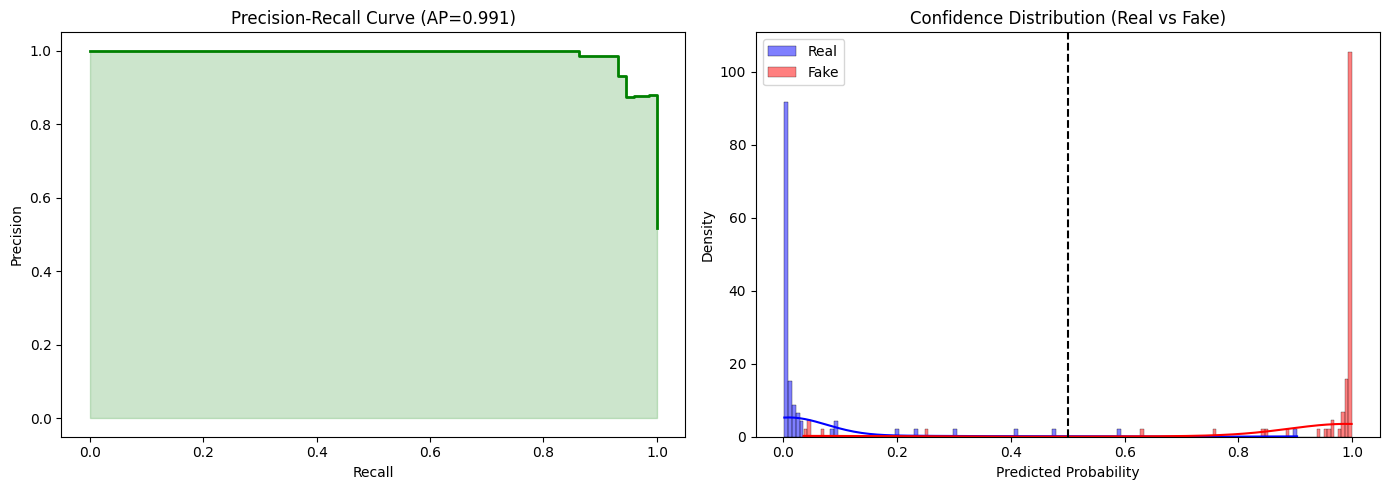


--- Detailed Classification Report ---
              precision    recall  f1-score   support

        Real       0.93      0.97      0.95        68
        Fake       0.97      0.93      0.95        73

    accuracy                           0.95       141
   macro avg       0.95      0.95      0.95       141
weighted avg       0.95      0.95      0.95       141



In [ ]:
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    matthews_corrcoef,
    classification_report
)
import pandas as pd
import seaborn as sns

@torch.no_grad()
def evaluate_all_metrics(model, name, loader, is_temporal=False):
    model.eval()
    y_true, y_prob = [], []

    print(f" Calculating full metrics for {name}...")
    for imgs, labels in loader:
        imgs = imgs.to(device)
        with torch.amp.autocast('cuda'):
            if is_temporal:
                logits = model(imgs)
            else:
                B, T, C, H, W = imgs.shape
                logits = model(imgs.view(B * T, C, H, W)).view(B, T, 1).mean(dim=1)

        # Apply sigmoid to convert logits to probabilities [0, 1]
        probs = torch.sigmoid(logits)
        y_prob.extend(probs.cpu().numpy().flatten())
        y_true.extend(labels.numpy().flatten())

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = (y_prob > 0.5).astype(int)

    # 1. Statistical Metrics
    metrics = {
        "Accuracy": (y_pred == y_true).mean(),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "Avg Precision": average_precision_score(y_true, y_prob)
    }

    # 2. Display Table
    df_metrics = pd.DataFrame([metrics], index=[name])
    print("\n--- Summary Table ---")
    display(df_metrics.round(4))

    # 3. Visualizations: Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_true, y_prob)

    plt.figure(figsize=(14, 5))

    # Subplot 1: Precision-Recall Curve
    plt.subplot(1, 2, 1)
    plt.step(recall, precision, where='post', color='green', lw=2)
    plt.fill_between(recall, precision, step='post', alpha=0.2, color='green')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve (AP={metrics["Avg Precision"]:.3f})')

    # Subplot 2: Probability Distribution (Helps see model confidence)
    plt.subplot(1, 2, 2)
    sns.histplot(y_prob[y_true == 0], color="blue", label="Real", kde=True, stat="density", alpha=0.5)
    sns.histplot(y_prob[y_true == 1], color="red", label="Fake", kde=True, stat="density", alpha=0.5)
    plt.axvline(0.5, color='black', linestyle='--')
    plt.title('Confidence Distribution (Real vs Fake)')
    plt.xlabel('Predicted Probability')
    plt.legend()

    plt.tight_layout()
    plt.show()

    print("\n--- Detailed Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=['Real', 'Fake']))

# Execute
evaluate_all_metrics(meso, "MesoNet", test_loader, is_temporal=False)
evaluate_all_metrics(lstm, "CNN-LSTM", test_loader, is_temporal=True)

## Conclusion & Next Steps

You now have a complete educational story:
- Traditional features → 62%
- baseline MesoNet (compression expert) → big jump
- CNN+LSTM → best because it sees motion

CNN+LSTM ~95%

